# Q10





In [1]:
import numpy as np

#stock prices of A and B matrix is here

stockprices=np.array([[100,108,103,115,110,119,125,121,130,127,135,140],[200,195,210,205,220,215,225,230,222,235,240,238]])
print("Array size:",stockprices.shape)


# (a)part

#simple return formula
#simple return = (new price - old price) / old price
simplereturns=((stockprices[:,1 :])-(stockprices[:,:-1]))/(stockprices[:,: -1])
print("Simple returns matrix :",simplereturns)
print("Array size:",simplereturns.shape)

# (b)part

# annualised mean return formula
annual_mean = np.mean(simplereturns,axis=1) * 12

# annualised volatility/standard deviation
annual_standardD = np.std(simplereturns,axis=1) * np.sqrt(12)

print("\nAnnual Mean returns matrix is here :")
print(annual_mean)
print("Annual Standard Deviations matrix is here :")
print(annual_standardD)

# (c)part

# covariance matrix
cov_matrix = np.cov(simplereturns)
print("\nCovariance Matrix is here :")
print(cov_matrix)

# correlation coefficient
rho = np.corrcoef(simplereturns)[0,1]

# standard deviations
sigma_A = np.std(simplereturns[0], ddof=1)
sigma_B = np.std(simplereturns[1], ddof=1)
# checking rho*sigmaA*sigmaB
check = rho * sigma_A * sigma_B

print("Cov(A,B):", cov_matrix[0,1])
print("rho*sigmaA*sigmaB:", check)

Array size: (2, 12)
Simple returns matrix : [[ 0.08       -0.0462963   0.11650485 -0.04347826  0.08181818  0.05042017
  -0.032       0.07438017 -0.02307692  0.06299213  0.03703704]
 [-0.025       0.07692308 -0.02380952  0.07317073 -0.02272727  0.04651163
   0.02222222 -0.03478261  0.05855856  0.0212766  -0.00833333]]
Array size: (2, 11)

Annual Mean returns matrix is here :
[0.39087388 0.20073826]
Annual Standard Deviations matrix is here :
[0.19259375 0.13903413]

Covariance Matrix is here :
[[ 0.00340013 -0.00206426]
 [-0.00206426  0.00177196]]
Cov(A,B): -0.0020642605060094284
rho*sigmaA*sigmaB: -0.0020642605060094284


# Q11


In [2]:
import numpy as np

# (a) part

# expected returns vector
mu = np.array([0.15,0.08,0.05])

# covariance matrix
sigma = np.array([
    [0.0400,0.0060,0.0040],
    [0.0060,0.0100,0.0020],
    [0.0040,0.0020,0.0025]
])

# equal weight portfolio
w = np.array([1/3,1/3,1/3])

# expected portfolio return
portfolio_return = w @ mu

# portfolio variance
portfolio_variance = w @ sigma @ w

# portfolio volatility
portfolio_volatility = np.sqrt(portfolio_variance)

print("Expected Portfolio Return is :",portfolio_return)
print("Portfolio Variance is :",portfolio_variance)
print("Portfolio Volatility is :",portfolio_volatility)

# (b) part

# generating 10000 random weight vectors
weights = np.random.dirichlet(np.ones(3),10000)

# expected portfolio returns
portfolio_returns = weights @ mu

# portfolio variances
portfolio_variances = np.sum((weights @ sigma) * weights , axis=1)

# portfolio volatilities
portfolio_volatilities = np.sqrt(portfolio_variances)

print("\nPortfolio Returns shape is :",portfolio_returns.shape)
print("Portfolio Volatility shape is :",portfolio_volatilities.shape)


# (c) part

# risk free rate
rf = 0.03

# sharpe ratios
sharpe_ratios = (portfolio_returns - rf) / portfolio_volatilities

# maximum sharpe ratio index
best_index = np.argmax(sharpe_ratios)

# best portfolio weights
best_weights = weights[best_index]

print("\nMaximum Sharpe Ratio is :",sharpe_ratios[best_index])
print("Best Portfolio Weights are :",best_weights)
print("Best Portfolio Return is :",portfolio_returns[best_index])
print("Best Portfolio Volatility is :",portfolio_volatilities[best_index])


Expected Portfolio Return is : 0.09333333333333332
Portfolio Variance is : 0.008499999999999999
Portfolio Volatility is : 0.09219544457292887

Portfolio Returns shape is : (10000,)
Portfolio Volatility shape is : (10000,)

Maximum Sharpe Ratio is : 0.6910384050539525
Best Portfolio Weights are : [0.32903272 0.45138588 0.2195814 ]
Best Portfolio Return is : 0.09644484875646502
Best Portfolio Volatility is : 0.0961521794888916


# Q12

In [3]:
import numpy as np

# given values
mu1 = 0.12
sigma1 = 0.20

mu2 = 0.06
sigma2 = 0.10

w1 = 0.6
w2 = 1 - w1


# (a) part

# creating 200 correlation values between -1 and 1
rho = np.linspace(-1,1,200)

# portfolio variance formula
# sigma_p^2 = w1^2*sigma1^2 + w2^2*sigma2^2 + 2*w1*w2*rho*sigma1*sigma2

portfolio_variance = (w1**2)*(sigma1**2) + (w2**2)*(sigma2**2) + (2*w1*w2*rho*sigma1*sigma2)

# portfolio volatility
portfolio_volatility = np.sqrt(portfolio_variance)

print("Portfolio volatility array is :")
print(portfolio_volatility)
print("Shape of volatility array is :",portfolio_volatility.shape)


# (b) part

# minimum volatility index
min_index = np.argmin(portfolio_volatility)

# rho value where volatility is minimum
best_rho = rho[min_index]

# minimum volatility
min_volatility = portfolio_volatility[min_index]

print("\nRho value where volatility is minimum :",best_rho)
print("Minimum portfolio volatility is :",min_volatility)


# (c) part

# analytical verification

# derivative of variance with respect to rho:
# d(sigma_p^2)/d(rho) = 2*w1*w2*sigma1*sigma2

print("\nAnalytical Verification :")
print("d(sigma_p^2)/d(rho) = 2*w1*w2*sigma1*sigma2")

derivative = 2*w1*w2*sigma1*sigma2

print("Derivative value is :",derivative)
print("Since derivative is positive,")
print("portfolio variance increases as rho increases.")
print("Therefore minimum variance occurs at boundary rho = -1")

Portfolio volatility array is :
[0.08       0.08060076 0.08119707 0.08178904 0.08237675 0.0829603
 0.08353978 0.08411526 0.08468683 0.08525457 0.08581855 0.08637885
 0.08693554 0.08748869 0.08803837 0.08858463 0.08912754 0.08966717
 0.09020357 0.09073679 0.09126691 0.09179396 0.092318   0.09283908
 0.09335726 0.09387257 0.09438508 0.09489481 0.09540182 0.09590615
 0.09640784 0.09690694 0.09740348 0.0978975  0.09838903 0.09887813
 0.09936482 0.09984913 0.10033111 0.10081078 0.10128819 0.10176335
 0.1022363  0.10270708 0.10317571 0.10364221 0.10410663 0.10456899
 0.10502931 0.10548762 0.10594395 0.10639832 0.10685076 0.10730129
 0.10774994 0.10819673 0.10864168 0.10908482 0.10952616 0.10996573
 0.11040355 0.11083965 0.11127403 0.11170672 0.11213775 0.11256712
 0.11299486 0.11342099 0.11384553 0.11426848 0.11468988 0.11510974
 0.11552806 0.11594488 0.11636021 0.11677406 0.11718645 0.11759739
 0.1180069  0.11841499 0.11882169 0.11922699 0.11963092 0.1200335
 0.12043472 0.12083462 0.1212331

# Q13,Q14


In [4]:
# 13


import pandas as pd
import numpy as np


# creating weekly stock prices data

np.random.seed(0)

dates = pd.date_range('2023-01-02', periods=52, freq='W-MON')

mu_weekly = np.array([0.003,0.002,0.001,0.0015])

sig_weekly = np.array([0.04,0.03,0.02,0.025])

returns_sim = np.random.normal(mu_weekly,sig_weekly,(52,4))

prices_sim = 100 * np.cumprod(1 + returns_sim, axis=0)

df = pd.DataFrame(
    prices_sim,
    index=dates,
    columns=['AAPL','MSFT','GOOGL','AMZN']
)

print("Stock prices data is :")
print(df.head())


# (a) part

# simple returns formula
# return = (new price - old price) / old price

weekly_returns = df.pct_change().dropna()
print("\nFirst 3 rows of weekly returns are :")
print(weekly_returns.head(3))
print("\nShape of returns dataframe is :")
print(weekly_returns.shape)


# (b) part

# describing returns dataframe
describe_data = weekly_returns.describe()
print("\nDescription table is :")
print(describe_data)

# highest mean return stock
highest_mean = weekly_returns.mean().idxmax()

# highest standard deviation stock
highest_std = weekly_returns.std().idxmax()
print("\nStock with highest mean return is :", highest_mean)
print("Stock with highest standard deviation is :", highest_std)


# (c) part

# sharpe ratio formula
# sharpe ratio = (return - risk free rate) / volatility

rf = 0.02

# annual returns
annual_returns = weekly_returns.mean() * 52

# annual volatility
annual_volatility = weekly_returns.std() * np.sqrt(52)

# sharpe ratio calculation
sharpe_ratio = (annual_returns - rf) / annual_volatility
print("\nAnnual returns are :")
print(annual_returns)
print("\nAnnual volatility is :")
print(annual_volatility)
print("\nSharpe ratios are :")
print(sharpe_ratio)

# Q14


# (a) part

# correlation matrix using corr()

corr_matrix = weekly_returns.corr()
print("Correlation matrix is :")
print(corr_matrix)

# finding lowest correlation pair

lowest_corr = corr_matrix.where(corr_matrix != 1).min().min()
print("\nLowest correlation value is :", lowest_corr)



# (b) part

# equal weights portfolio

weights = pd.Series(
    [0.25,0.25,0.25,0.25],
    index=['AAPL','MSFT','GOOGL','AMZN']
)

# portfolio returns using dot()

portfolio_returns = weekly_returns.dot(weights)
print("\nPortfolio returns series is :")
print(portfolio_returns.head())



# (c) part

# converting weekly returns to monthly returns

monthly_returns = portfolio_returns.resample('ME').apply(
    lambda x : (1 + x).prod() - 1
)
print("\nMonthly returns are :")
print(monthly_returns)

# mean and standard deviation

monthly_mean = monthly_returns.mean()
monthly_std = monthly_returns.std()

print("\nMean of monthly returns is :", monthly_mean)
print("Standard deviation of monthly returns is :", monthly_std)

Stock prices data is :
                  AAPL        MSFT       GOOGL        AMZN
2023-01-02  107.356209  101.400472  102.057476  105.752233
2023-01-09  115.698036   98.630379  104.098806  105.510702
2023-01-16  115.567441  100.042565  104.502800  109.505004
2023-01-23  119.432191  100.607830  105.535002  110.582737
2023-01-30  126.928133  100.189830  106.301329  108.387405

First 3 rows of weekly returns are :
                AAPL      MSFT     GOOGL      AMZN
2023-01-09  0.077702 -0.027318  0.020002 -0.002284
2023-01-16 -0.001129  0.014318  0.003881  0.037857
2023-01-23  0.033442  0.005650  0.009877  0.009842

Shape of returns dataframe is :
(51, 4)

Description table is :
            AAPL       MSFT      GOOGL       AMZN
count  51.000000  51.000000  51.000000  51.000000
mean    0.005603   0.002192  -0.000887   0.006094
std     0.045641   0.032819   0.017055   0.022948
min    -0.099120  -0.057424  -0.033125  -0.054085
25%    -0.030293  -0.025056  -0.013135  -0.006813
50%     0.001429

# Q15

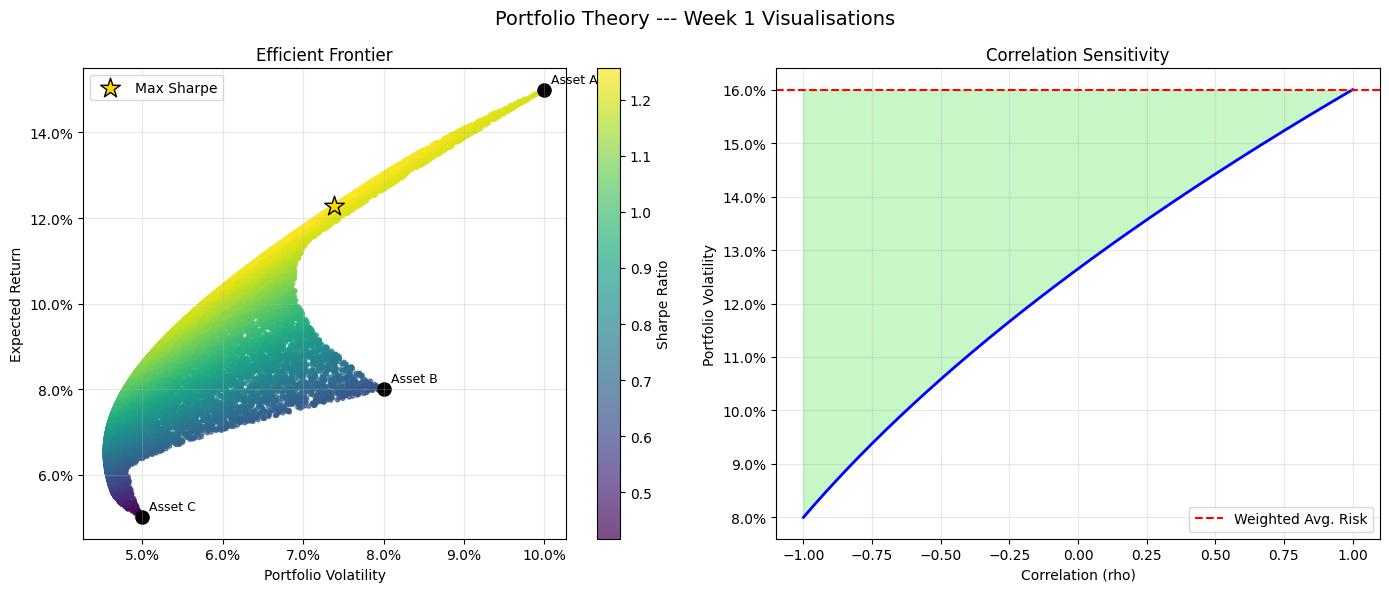

Maximum Sharpe Ratio is : 1.2562344714562466
Best Portfolio Return is : 0.12275214438911043
Best Portfolio Volatility is : 0.07383346540522065


In [5]:

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

np.random.seed(42)

# --------------------------------------------------
# 3 asset universe from Question 11
# --------------------------------------------------
mu = np.array([0.15, 0.08, 0.05])
cov = np.array([
    [0.0100, 0.0018, 0.0011],
    [0.0018, 0.0064, 0.0009],
    [0.0011, 0.0009, 0.0025]
])

rf = 0.03

# --------------------------------------------------
# simulate 20000 random portfolios
# --------------------------------------------------

n_portfolios = 20000
weights = np.random.dirichlet(np.ones(3), n_portfolios)
portfolio_returns = weights @ mu
portfolio_volatility = np.sqrt(
    np.einsum('ij,jk,ik->i', weights, cov, weights)
)

# sharpe ratios

sharpe_ratios = (portfolio_returns - rf) / portfolio_volatility

# --------------------------------------------------
# maximum sharpe portfolio
# --------------------------------------------------

best_index = np.argmax(sharpe_ratios)
best_return = portfolio_returns[best_index]
best_volatility = portfolio_volatility[best_index]

# --------------------------------------------------
# individual assets
# --------------------------------------------------

asset_returns = mu

asset_volatility = np.sqrt(np.diag(cov))

asset_names = ['Asset A', 'Asset B', 'Asset C']

# --------------------------------------------------
# question 12 setup
# --------------------------------------------------

mu1 = 0.12
mu2 = 0.06

sigma1 = 0.20
sigma2 = 0.10

w1 = 0.6
w2 = 0.4

# rho values
rho = np.linspace(-1, 1, 200)

# portfolio volatility
sigma_p = np.sqrt(
    (w1**2)*(sigma1**2) +
    (w2**2)*(sigma2**2) +
    2*w1*w2*rho*sigma1*sigma2
)

# weighted average risk
weighted_risk = w1*sigma1 + w2*sigma2

# --------------------------------------------------
# plotting
# --------------------------------------------------

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# ==================================================
# subplot 1 : efficient frontier
# ==================================================
scatter = ax[0].scatter(
    portfolio_volatility,
    portfolio_returns,
    c=sharpe_ratios,
    cmap='viridis',
    s=8,
    alpha=0.7
)

# maximum sharpe portfolio
ax[0].scatter(
    best_volatility,
    best_return,
    color='gold',
    marker='*',
    s=220,
    edgecolor='black',
    label='Max Sharpe'
)

# individual assets
ax[0].scatter(
    asset_volatility,
    asset_returns,
    color='black',
    s=90
)

# asset labels
for i in range(3):
    ax[0].annotate(
        asset_names[i],
        (asset_volatility[i], asset_returns[i]),
        xytext=(5, 5),
        textcoords='offset points',
        fontsize=9
    )

# labels and title
ax[0].set_title('Efficient Frontier', fontsize=12)
ax[0].set_xlabel('Portfolio Volatility')
ax[0].set_ylabel('Expected Return')

# percentage formatting
ax[0].xaxis.set_major_formatter(PercentFormatter(1))
ax[0].yaxis.set_major_formatter(PercentFormatter(1))

# colorbar
cbar = fig.colorbar(scatter, ax=ax[0])
cbar.set_label('Sharpe Ratio')
ax[0].legend()
ax[0].grid(alpha=0.3)

# ==================================================
# subplot 2 : correlation sensitivity
# ==================================================

ax[1].plot(
    rho,
    sigma_p,
    color='blue',
    linewidth=2
)

# weighted average risk line

ax[1].axhline(
    weighted_risk,
    color='red',
    linestyle='--',
    label='Weighted Avg. Risk'
)

# shaded region

ax[1].fill_between(
    rho,
    sigma_p,
    weighted_risk,
    where=(sigma_p < weighted_risk),
    color='lightgreen',
    alpha=0.5
)

# labels and title
ax[1].set_title('Correlation Sensitivity', fontsize=12)
ax[1].set_xlabel('Correlation (rho)')
ax[1].set_ylabel('Portfolio Volatility')

# percentage formatting
ax[1].yaxis.set_major_formatter(PercentFormatter(1))
ax[1].legend()
ax[1].grid(alpha=0.3)

# --------------------------------------------------
# overall title
# --------------------------------------------------

fig.suptitle(
    'Portfolio Theory --- Week 1 Visualisations',
    fontsize=14
)
plt.tight_layout()

# save figure
plt.savefig('week1_plots.png', dpi=150)
plt.show()

# --------------------------------------------------
# outputs
# --------------------------------------------------
print("Maximum Sharpe Ratio is :", sharpe_ratios[best_index])
print("Best Portfolio Return is :", best_return)
print("Best Portfolio Volatility is :", best_volatility)

